In [15]:
import re

import joblib
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, average_precision_score,
                             classification_report, roc_auc_score)
from sklearn.model_selection import (StratifiedKFold, TunedThresholdClassifierCV,
                                     cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from lightgbm import LGBMClassifier   # <-- CatBoost yerine

SEED = 42
np.random.seed(SEED)


In [16]:
df = pd.read_csv("../data/raw/training_v2.csv")
display(df.head(3))

target_col = "hospital_death"

# Gereksiz/sızıntı sütunlarını çıkarma:
# - id_cols: encounter_id, patient_id, hospital_id, icu_id -> kimlik/ünite sütunları, klinik ölçüm değil.
# - leakage_cols: apache_4a_* death prob -> önceden hesaplanmış ölüm olasılığı; hedefi sızdırır.
id_cols      = ["encounter_id", "patient_id", "hospital_id", "icu_id"]
leakage_cols = ["apache_4a_hospital_death_prob", "apache_4a_icu_death_prob"]
df.drop(columns=id_cols + leakage_cols, inplace=True)

y_raw = df[target_col]

if y_raw.dtype.kind in "OUSb":
    cat = pd.Categorical(y_raw)
    y = pd.Series(cat.codes, index=y_raw.index, name=target_col)
else:
    y = pd.Series(y_raw.astype(int), name=target_col)

X = df.drop(columns=[target_col])
display(X.head(3))
print(f"X shape: {X.shape} | death rate: {y.mean():.3f}")


,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.73,0,Caucasian,M,180.3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.42,0,Caucasian,F,160.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.95,0,Caucasian,F,172.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic


,age,bmi,elective_surgery,ethnicity,gender,height,hospital_admit_source,icu_admit_source,icu_stay_type,icu_type,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,68.0,22.73,0,Caucasian,M,180.3,Floor,Floor,admit,CTICU,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,77.0,27.42,0,Caucasian,F,160.0,Floor,Floor,admit,Med-Surg ICU,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,25.0,31.95,0,Caucasian,F,172.7,Emergency Department,Accident & Emergency,admit,Med-Surg ICU,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic


X shape: (91713, 179) | death rate: 0.086


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,          
)

print(f"X_train: {X_train.shape} | death rate: {y_train.mean():.3f}")
print(f"X_test : {X_test.shape} | death rate: {y_test.mean():.3f}")


X_train: (73370, 179) | death rate: 0.086
X_test : (18343, 179) | death rate: 0.086


In [18]:
from dataclasses import dataclass


@dataclass
class ColumnInfo:
    name: str
    dtype: str
    n_unique: int


In [19]:
column_info_list = [
    ColumnInfo(name=col, dtype=X[col].dtype, n_unique=X[col].nunique())
    for col in X.columns
]

for info in column_info_list:
    print(info)


ColumnInfo(name='age', dtype=dtype('float64'), n_unique=74)
ColumnInfo(name='bmi', dtype=dtype('float64'), n_unique=34888)
ColumnInfo(name='elective_surgery', dtype=dtype('int64'), n_unique=2)
ColumnInfo(name='ethnicity', dtype=dtype('O'), n_unique=6)
ColumnInfo(name='gender', dtype=dtype('O'), n_unique=2)
ColumnInfo(name='height', dtype=dtype('float64'), n_unique=401)
ColumnInfo(name='hospital_admit_source', dtype=dtype('O'), n_unique=15)
ColumnInfo(name='icu_admit_source', dtype=dtype('O'), n_unique=5)
ColumnInfo(name='icu_stay_type', dtype=dtype('O'), n_unique=3)
ColumnInfo(name='icu_type', dtype=dtype('O'), n_unique=8)
ColumnInfo(name='pre_icu_los_days', dtype=dtype('float64'), n_unique=9757)
ColumnInfo(name='readmission_status', dtype=dtype('int64'), n_unique=1)
ColumnInfo(name='weight', dtype=dtype('float64'), n_unique=3409)
ColumnInfo(name='albumin_apache', dtype=dtype('float64'), n_unique=35)
ColumnInfo(name='apache_2_diagnosis', dtype=dtype('float64'), n_unique=44)
ColumnInfo(

In [20]:
numeric_cols = []
binary_cols = []
ohe_cols = []
ordinal_cols = []   # bizde manuel ordinal yok (örnekte ncap_rating/airbags/cylinder vardı)

handled_cols = set(ordinal_cols)

for info in column_info_list:
    if info.name in handled_cols:
        continue

    # 2 benzersiz değer -> binary
    if info.n_unique == 2:
        binary_cols.append(info.name)
    # sayısal tip -> numeric
    elif np.issubdtype(info.dtype, np.number):
        numeric_cols.append(info.name)
    # kelime (object) tip -> one-hot
    elif info.dtype == "O":
        ohe_cols.append(info.name)
    else:
        print(f"Warning: Sütun '{info.name}' kategorize edilemedi.")

total_cols = len(column_info_list)
processed_cols_count = (
    len(numeric_cols) + len(binary_cols) + len(ohe_cols) + len(ordinal_cols)
)

assert total_cols == processed_cols_count, \
    f"Sütun sayısı tutarsız! Toplam: {total_cols}, pipeline: {processed_cols_count}"

print(f"Toplam {total_cols} sütun eşleşti")
print(f"Numeric ({len(numeric_cols)}): {numeric_cols}")
print(f"Binary ({len(binary_cols)}): {binary_cols}")
print(f"OHE ({len(ohe_cols)}): {ohe_cols}")
print(f"Ordinal ({len(ordinal_cols)}): {ordinal_cols}")


Toplam 179 sütun eşleşti
Numeric (157): ['age', 'bmi', 'height', 'pre_icu_los_days', 'readmission_status', 'weight', 'albumin_apache', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'bilirubin_apache', 'bun_apache', 'creatinine_apache', 'fio2_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_verbal_apache', 'glucose_apache', 'heart_rate_apache', 'hematocrit_apache', 'map_apache', 'paco2_apache', 'paco2_for_ph_apache', 'pao2_apache', 'ph_apache', 'resprate_apache', 'sodium_apache', 'temp_apache', 'urineoutput_apache', 'wbc_apache', 'd1_diasbp_invasive_max', 'd1_diasbp_invasive_min', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_invasive_max', 'd1_mbp_invasive_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min', 'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_invasive_max', 'd1_sysbp_invasive_min', 'd1_sysbp_max', 'd1_sysbp_min', 'd

In [21]:
# 1. Sayısal Sütunlar
# Eksik değerleri medyan ile doldur + standartlaştır.
# add_indicator=True -> eksiklik bayrağı sütunları da ekler (senin istediğin missingness indicator)
numeric_tf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]
)

# 2. İkili (Binary) Sütunlar
binary_tf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ]
)

# 3. One-Hot Encoding Sütunları
ohe_tf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            sparse_output=False,
            max_categories=10,
        )),
    ]
)

# 4. Sütun Yönlendirici (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, numeric_cols),
        ("bin", binary_tf, binary_cols),
        ("ohe", ohe_tf, ohe_cols),
    ],
    remainder="passthrough",
)


# data_prep doğrudan preprocessor.
data_prep_pipeline = preprocessor

print("--- Pipeline Oluşturuldu ---")


--- Pipeline Oluşturuldu ---


## Model Fitting

Amacımız, hangi modelin (Lojistik Regresyon, Karar Ağacı, Random Forest, LightGBM) ICU hasta mortalitesini (`hospital_death`) en iyi tahmin ettiğini bulmaktır. Ancak bunu yaparken, sonuçlarımızın şans eseri ya da tek bir veri ayırımına özgü olmadığından emin olmalıyız.

### Çapraz Doğrulama (Cross-Validation): Güvenilir Performans Ölçümü

**Problem:** `train_test_split` ile veriyi sadece bir kez ayırdığımızda, model performansı bu tek ayırıma bağlı kalır. Şans eseri "kolay" bir test seti denk gelirse, performansı olduğundan yüksek ölçebiliriz.

**Çözüm (StratifiedKFold):** Eğitim verisini 5 eşit "katmana" (fold) böleriz. Sırayla:

- **Deney 1:** 1. katman doğrulama, kalan 4 katman eğitim.
- **Deney 2:** 2. katman doğrulama, kalan 4 katman eğitim.
- ...5 deneyin tamamı yapılır.

**"Stratified" neden önemli?** Verimiz çok dengesiz — sadece **%8.6 ölüm**. Stratified, her katmandaki ölüm (1) / hayatta kalan (0) oranının orijinal veriyle **aynı** kalmasını sağlar. Dengesiz veride bu hayati.

**Nihai sonuç:** Performans, 5 deneyin **ortalaması** olarak hesaplanır — tek bir deneyden çok daha güvenilir ve stabil.

### Eşik (Threshold) Optimizasyonu (TunedThresholdClassifierCV)

**Problem:** Binary classification modelleri varsayılan olarak olasılık **0.5**'in üzerindeyse "1" (ölüm), altındaysa "0" der. Ama bizim gibi **dengesiz** veride en iyi ayrımı yapan eşik neredeyse hiçbir zaman 0.5 değildir.

**Çözüm:** `TunedThresholdClassifierCV`, bu süreci otomatikleştiren bir wrapper'dır. Her çapraz doğrulama deneyinde:
1. Modeli eğitir.
2. Bizim seçtiğimiz metriği (`scoring="f1"`) maksimize eden **en iyi eşiği** bulur ve kaydeder.

**Neden F1?** ICU'da bir ölümü kaçırmak (false negative) çok pahalıdır → **recall** önemli. Ama sadece recall'a bakarsak model herkese "ölür" der (precision çöker). **F1**, precision ile recall'ı dengeleyerek dengesiz veride sağlam bir orta yol sunar. (İstersek `scoring="recall"` ile kaçırmamayı daha çok önceleyebiliriz.)


In [22]:
from sklearn.model_selection import TunedThresholdClassifierCV


def get_threshold(estimator, X, y):
    # Pipeline'ın 'clf' adımına erişiyoruz (bu bizim TunedThresholdClassifierCV'miz)
    # ve eğitildikten sonra bulduğu en iyi eşiği (.best_threshold_) döndürüyoruz.
    return estimator.named_steps["clf"].best_threshold_


In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    "LogReg": TunedThresholdClassifierCV(
        estimator=LogisticRegression(max_iter=1000, solver="lbfgs", random_state=SEED),
        scoring="f1",  # Eşiği f1'i maksimize edecek şekilde bul
        cv=cv,
        random_state=SEED,
    ),
    "DecisionTree": TunedThresholdClassifierCV(
        estimator=DecisionTreeClassifier(max_depth=7, random_state=SEED),
        scoring="f1",
        cv=cv,
        random_state=SEED,
    ),
    "RandomForest": TunedThresholdClassifierCV(
        estimator=RandomForestClassifier(max_depth=7, random_state=SEED),
        scoring="f1",
        cv=cv,
        random_state=SEED,
    ),
    
}

pipelines = {
    name: Pipeline(steps=[("data_prep", data_prep_pipeline), ("clf", clf)])
    for name, clf in models.items()
}


### Tam Pipeline + Cross-Validation

Her bir model (`clf`) için, onu veri hazırlık pipeline'ımızla (`data_prep_pipeline`) birleştiren **tam bir pipeline** oluşturuyoruz.

Bu tam pipeline'ı `cross_validate`'e verdiğimizde, her çapraz doğrulama katmanı için şunlar **otomatik** gerçekleşir:

1. Veri hazırlık adımları (eksik doldurma, ölçekleme, kodlama, eksiklik bayrağı) **sadece o anki eğitim katmanına** uygulanır (`fit_transform`).
2. Model bu temizlenmiş eğitim katmanı üzerinde eğitilir.
3. Aynı hazırlık adımları, **eğitimde öğrenilen** parametrelerle doğrulama katmanına uygulanır (`transform`) — yani doğrulama katmanı kendi istatistiğini sızdırmaz.
4. Performans bu temizlenmiş doğrulama katmanında ölçülür.

Bu yapı **veri sızıntısını (data leakage) önler** — önceden scale/encode etmekten kaynaklanan klasik hataları engeller.

`cross_validate`, bu sürecin tamamını (CV bölme, pipeline çalıştırma, skor hesaplama) **dört modelimiz için de** (LogReg, DecisionTree, RandomForest, LightGBM) tek tek çalıştırır.

`scoring=scorers` parametresi sayesinde her model için sadece **F1** değil; aynı zamanda **recall**, **roc_auc** gibi dengesiz veride önemli metrikleri ve özel `get_threshold` fonksiyonumuzla bulunan **en iyi eşik değerini** de hesaplar.


In [24]:
scorers = {
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",  # AUPRC - dengesiz veride önemli (senin projende vurgulanan metrik)
    "threshold": get_threshold,
}

results = {}

for name, pipe in pipelines.items():
    print(f"Model: {name}")
    cv_res = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scorers,
        return_train_score=False,
        verbose=3,
    )
    found_thresholds = cv_res["test_threshold"]
    print(f"\t... Bulunan Eşik Değerleri: {[f'{th:.3f}' for th in found_thresholds]}")
    print(f"\t... Ortalama Eşik Değeri: {np.mean(found_thresholds):.3f}")
    results[name] = cv_res


Model: LogReg


[CV] END  average_precision: (test=0.536) f1: (test=0.512) precision: (test=0.499) recall: (test=0.525) roc_auc: (test=0.888) threshold: (test=0.252) total time=  20.2s
[CV] END  average_precision: (test=0.508) f1: (test=0.494) precision: (test=0.491) recall: (test=0.496) roc_auc: (test=0.877) threshold: (test=0.263) total time=  19.5s
[CV] END  average_precision: (test=0.526) f1: (test=0.523) precision: (test=0.503) recall: (test=0.545) roc_auc: (test=0.885) threshold: (test=0.242) total time=  18.8s
[CV] END  average_precision: (test=0.513) f1: (test=0.495) precision: (test=0.449) recall: (test=0.553) roc_auc: (test=0.885) threshold: (test=0.222) total time=  21.2s
[CV] END  average_precision: (test=0.493) f1: (test=0.495) precision: (test=0.451) recall: (test=0.548) roc_auc: (test=0.884) threshold: (test=0.222) total time=  22.6s
	... Bulunan Eşik Değerleri: ['0.252', '0.263', '0.242', '0.222', '0.222']
	... Ortalama Eşik Değeri: 0.240
Model: DecisionTree


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.7min finished


[CV] END  average_precision: (test=0.401) f1: (test=0.436) precision: (test=0.382) recall: (test=0.507) roc_auc: (test=0.823) threshold: (test=0.162) total time=  13.5s
[CV] END  average_precision: (test=0.386) f1: (test=0.412) precision: (test=0.378) recall: (test=0.451) roc_auc: (test=0.811) threshold: (test=0.182) total time=  13.1s
[CV] END  average_precision: (test=0.409) f1: (test=0.427) precision: (test=0.409) recall: (test=0.446) roc_auc: (test=0.819) threshold: (test=0.192) total time=  11.5s
[CV] END  average_precision: (test=0.392) f1: (test=0.418) precision: (test=0.346) recall: (test=0.526) roc_auc: (test=0.816) threshold: (test=0.172) total time=  11.7s
[CV] END  average_precision: (test=0.380) f1: (test=0.418) precision: (test=0.374) recall: (test=0.475) roc_auc: (test=0.811) threshold: (test=0.172) total time=  11.9s
	... Bulunan Eşik Değerleri: ['0.162', '0.182', '0.192', '0.172', '0.172']
	... Ortalama Eşik Değeri: 0.176
Model: RandomForest


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.0min finished


[CV] END  average_precision: (test=0.515) f1: (test=0.506) precision: (test=0.494) recall: (test=0.518) roc_auc: (test=0.872) threshold: (test=0.195) total time=  37.1s
[CV] END  average_precision: (test=0.478) f1: (test=0.462) precision: (test=0.472) recall: (test=0.451) roc_auc: (test=0.855) threshold: (test=0.204) total time=  36.4s
[CV] END  average_precision: (test=0.513) f1: (test=0.503) precision: (test=0.477) recall: (test=0.532) roc_auc: (test=0.871) threshold: (test=0.182) total time=  36.4s
[CV] END  average_precision: (test=0.477) f1: (test=0.479) precision: (test=0.455) recall: (test=0.506) roc_auc: (test=0.860) threshold: (test=0.191) total time=  36.5s
[CV] END  average_precision: (test=0.480) f1: (test=0.469) precision: (test=0.469) recall: (test=0.468) roc_auc: (test=0.863) threshold: (test=0.198) total time=  36.4s
	... Bulunan Eşik Değerleri: ['0.195', '0.204', '0.182', '0.191', '0.198']
	... Ortalama Eşik Değeri: 0.194


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  3.0min finished


In [25]:
results

{'LogReg': {'fit_time': array([19.85163713, 19.25267386, 18.52812505, 20.88323689, 22.17364001]),
  'score_time': array([0.30286002, 0.27027202, 0.27189207, 0.33226585, 0.38442707]),
  'test_f1': array([0.51173528, 0.49372057, 0.52292535, 0.49539986, 0.49500713]),
  'test_recall': array([0.52486188, 0.4964483 , 0.5450237 , 0.55292259, 0.54818325]),
  'test_precision': array([0.49924925, 0.49102264, 0.50254916, 0.44871795, 0.45123537]),
  'test_roc_auc': array([0.88771407, 0.87657027, 0.88542362, 0.88476781, 0.88441658]),
  'test_average_precision': array([0.53628984, 0.50833051, 0.52609921, 0.51305198, 0.49265571]),
  'test_threshold': array([0.25247509, 0.26265405, 0.24241286, 0.22211591, 0.22220058])},
 'DecisionTree': {'fit_time': array([13.33464479, 12.91377425, 11.36410975, 11.53802085, 11.75781298]),
  'score_time': array([0.19456196, 0.18605089, 0.16964126, 0.17790794, 0.18642616]),
  'test_f1': array([0.43569732, 0.41151079, 0.42673716, 0.41755486, 0.41808696]),
  'test_recall'

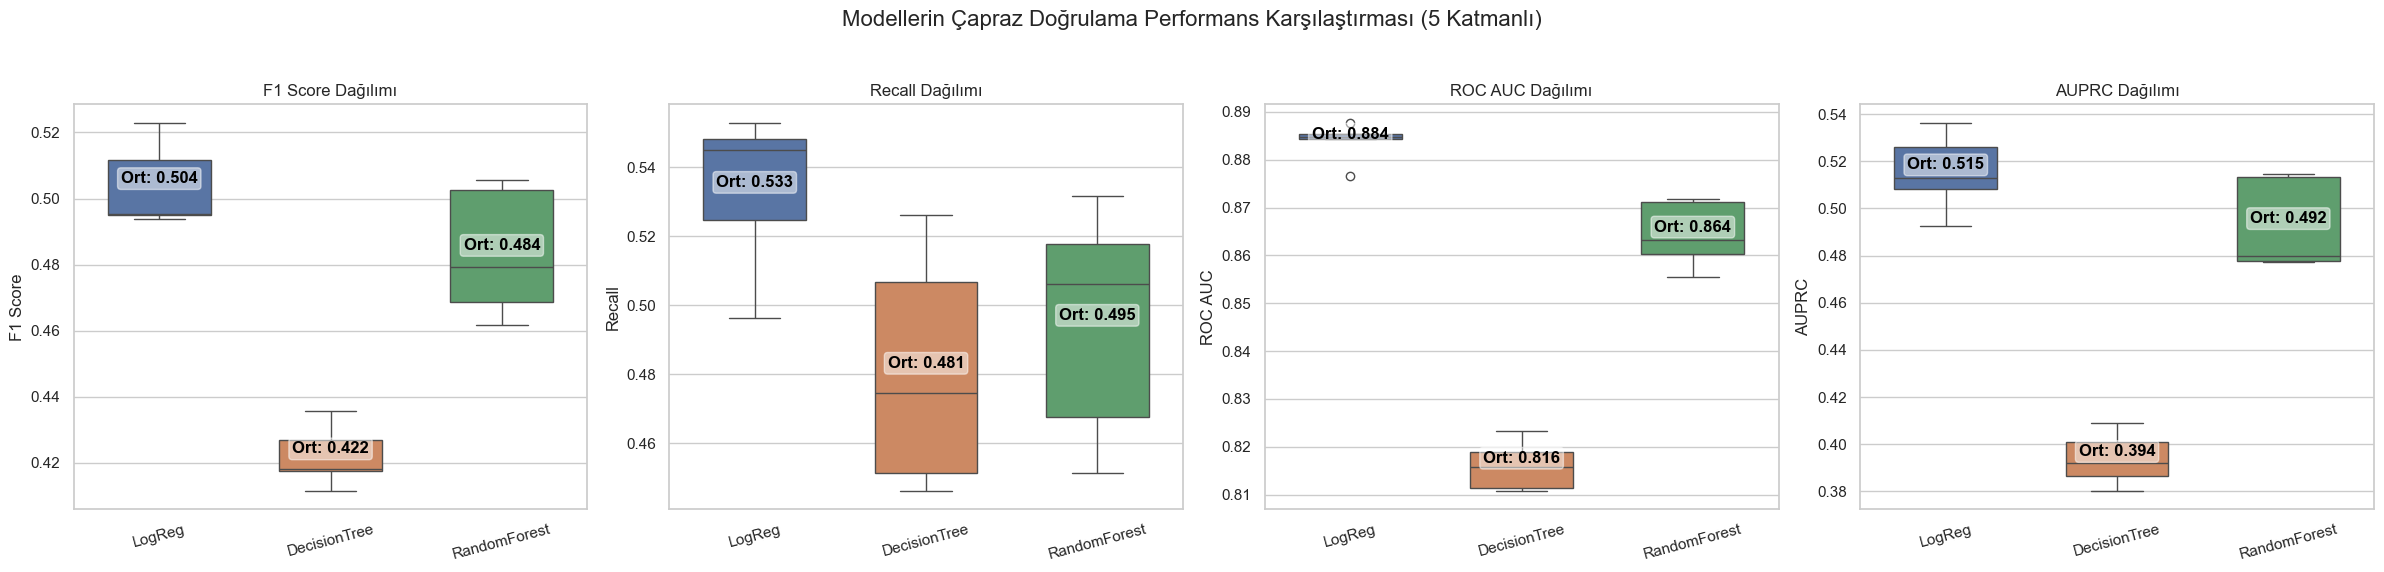

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = []
metrics_to_plot = {
    "F1 Score": "test_f1",
    "Recall": "test_recall",
    "ROC AUC": "test_roc_auc",
    "AUPRC": "test_average_precision",   # senin ana metriğin, dengesiz veride önemli
}

for model_name, model_results in results.items():
    for plot_name, internal_name in metrics_to_plot.items():
        for score in model_results[internal_name]:
            plot_data.append({"Model": model_name, "Metric": plot_name, "Score": score})

df_plot = pd.DataFrame(plot_data)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(24, 6), sharey=False)
fig.suptitle(
    "Modellerin Çapraz Doğrulama Performans Karşılaştırması (5 Katmanlı)", fontsize=16
)

for i, (plot_name, internal_name) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    metric_df = df_plot[df_plot["Metric"] == plot_name]

    sns.boxplot(
        x="Model", y="Score", data=metric_df, ax=ax,
        hue="Model", palette="deep", width=0.6, legend=False,  # hue+legend=False -> palette uyarısı çıkmaz
    )

    ax.set_title(f"{plot_name} Dağılımı")
    ax.set_xlabel("")
    ax.set_ylabel(plot_name)
    ax.tick_params(axis="x", rotation=15)

    for j, model in enumerate(metric_df["Model"].unique()):
        mean_val = results[model][internal_name].mean()
        ax.text(
            j, mean_val, f"Ort: {mean_val:.3f}",
            ha="center", va="bottom", fontweight="bold", color="black",
            bbox=dict(facecolor="white", alpha=0.5, boxstyle="round,pad=0.2"),
        )

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Model: RandomForest

Classification Report (Test):

              precision    recall  f1-score   support

           0     0.9556    0.9428    0.9491     16760
           1     0.4693    0.5357    0.5003      1583

    accuracy                         0.9076     18343
   macro avg     0.7124    0.7392    0.7247     18343
weighted avg     0.9136    0.9076    0.9104     18343

ROC-AUC (test): 0.8725 | AUPRC (PR-AUC): 0.5282
Kullanılan en iyi eşik: 0.189


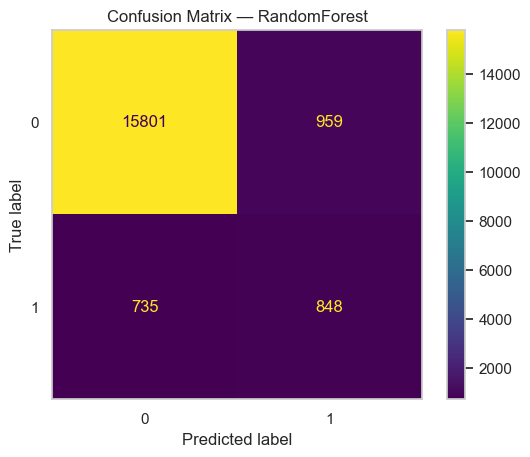

In [27]:
best_model_name = "RandomForest"   # senin seçimin
best_pipe = pipelines[best_model_name]
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)
print(f"Model: {best_model_name}")
print("\nClassification Report (Test):\n")
print(classification_report(y_test, y_pred, digits=4))

if hasattr(best_pipe.named_steps["clf"], "predict_proba"):
    y_proba = best_pipe.predict_proba(X_test)[:, 1]
    roc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    print(f"ROC-AUC (test): {roc:.4f} | AUPRC (PR-AUC): {ap:.4f}")

# TunedThresholdClassifierCV'nin bulduğu en iyi eşik
best_threshold = best_pipe.named_steps["clf"].best_threshold_
print(f"Kullanılan en iyi eşik: {best_threshold:.3f}")

ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.grid(False)
plt.show()


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier

# SqrtBalanced karşılığı: sqrt(negatif / pozitif) (~3.3) — bir kez hesapla
sqrt_scale_pos_weight = np.sqrt((y_train == 0).sum() / (y_train == 1).sum())
print("scale_pos_weight (SqrtBalanced):", round(sqrt_scale_pos_weight, 3))


def objective(trial):

    params = {
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0),          # l2_leaf_reg karşılığı
        "n_estimators": trial.suggest_int("n_estimators", 400, 2000),        # iterations karşılığı
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "scale_pos_weight": sqrt_scale_pos_weight,   # auto_class_weights="SqrtBalanced" karşılığı
        "random_state": SEED,
        "verbose": -1,
    }

    # NOT: Eşik (threshold) optimizasyonunu burada YAPMIYORUZ.
    # AUPRC eşikten bağımsız bir metrik -> hiperparametreyi temiz buluruz.
    # En iyi eşiği, en iyi parametreleri bulduktan SONRA ayrı adımda
    # (TunedThresholdClassifierCV ile) ayarlayacağız.

    clf = LGBMClassifier(**params)
    pipe = Pipeline(steps=[("data_prep", data_prep_pipeline), ("clf", clf)])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision")

    return scores.mean()


# Optuna her denemede objective'i çalıştırır, dönen skoru (CV ortalama AUPRC) kaydeder
# ve bir sonraki denemede daha "akıllı" parametre seti önerir.
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("\nEn iyi skor (CV ortalama AUPRC):", study.best_value)
print("En iyi hiperparametreler:\n", study.best_params)


In [28]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from lightgbm import LGBMClassifier


def objective(trial):

    params = {
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 10.0),          # l2_leaf_reg karşılığı
        "n_estimators": trial.suggest_int("n_estimators", 400, 2000),        # iterations karşılığı
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "class_weight": "balanced",   # auto_class_weights yerine
        "random_state": SEED,
        "verbose": -1,
    }

    clf = LGBMClassifier(**params)
    pipe = Pipeline(steps=[("data_prep", data_prep_pipeline), ("clf", clf)])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")  # eval_metric="AUC" karşılığı

    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("\nEn iyi skor (CV ortalama AUC):", study.best_value)
print("En iyi hiperparametreler:\n", study.best_params)


[I 2026-06-05 01:16:23,930] A new study created in memory with name: no-name-b5e5e6b9-4bac-4914-aaf8-9c7397feaa50


  0%|          | 0/10 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2026-06-05 01:17:55,306] Trial 0 finished with value: 0.8949654152331021 and parameters: {'max_depth': 9, 'num_leaves': 101, 'learning_rate': 0.10650375236706189, 'reg_lambda': 6.849105885642836, 'n_estimators': 879, 'min_child_samples': 50, 'subsample': 0.6739561276845607, 'colsample_bytree': 0.9606563045035166}. Best is trial 0 with value: 0.8949654152331021.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

[I 2026-06-05 01:28:49,740] Trial 7 finished with value: 0.9020323417912077 and parameters: {'max_depth': 8, 'num_leaves': 32, 'learning_rate': 0.005543614614122338, 'reg_lambda': 2.230680355545247, 'n_estimators': 1831, 'min_child_samples': 85, 'subsample': 0.9468119688178294, 'colsample_bytree': 0.9744966615817277}. Best is trial 6 with value: 0.9026603119494669.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2026-06-05 01:29:36,139] Trial 8 finished with value: 0.8909565849001689 and parameters: {'max_depth': 6, 'num_leaves': 29, 'learning_rate': 0.004952640291161831, 'reg_lambda': 1.6031040264975984, 'n_estimators': 694, 'min_child_samples': 19, 'subsample': 0.9412040553705334, 'colsample_bytree': 0.7674293709634351}. Best is trial 6 with value: 0.9026603119494669.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[I 2026-06-05 01:32:05,803] Trial 9 finished with value: 0.8920569030999459 and parameters: {'max_depth': 7, 'num_leaves': 113, 'learning_rate': 0.0016061716025064534, 'reg_lambda': 3.0304212524670184, 'n_estimators': 1708, 'min_child_samples': 100, 'subsample': 0.797407285439818, 'colsample_bytree': 0.9704553986897695}. Best is trial 6 with value: 0.9026603119494669.

En iyi skor (CV ortalama AUC): 0.9026603119494669
En iyi hiperparametreler:
 {'max_depth': 5, 'num_leaves': 57, 'learning_rate': 0.013868762536313799, 'reg_lambda': 7.692292078391939, 'n_estimators': 1921, 'min_child_samples': 32, 'subsample': 0.7647377968169441, 'colsample_bytree': 0.7148623268990745}


In [29]:
from sklearn.model_selection import TunedThresholdClassifierCV

# 1. En iyi parametrelerle temel LightGBM modeli
best_base_lgbm = LGBMClassifier(
    class_weight="balanced",     # objective'deki ile aynı (best_params'ta yok, elle ekle)
    subsample_freq=1,            # objective'de sabitti, best_params'ta yok, elle ekle
    random_state=SEED,
    n_jobs=-1,                   # thread_count=-1 karşılığı
    verbose=-1,
    **study.best_params,         # Optuna'nın bulduğu en iyi parametreler
)

# 2. En iyi modeli TunedThresholdClassifierCV ile sarmala -> .fit() en iyi eşiği bulup saklar
final_tuned_lgbm = TunedThresholdClassifierCV(
    estimator=best_base_lgbm,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    random_state=SEED,
)

# 3. Final pipeline (senin preprocessing'inle)
lgbm_pipe = Pipeline(
    steps=[("data_prep", data_prep_pipeline), ("clf", final_tuned_lgbm)]
)

# 4. Tüm eğitim verisiyle eğit -> en iyi eşik bulunur
lgbm_pipe.fit(X_train, y_train)

# 5. Bulunan en iyi eşik
best_threshold_found = lgbm_pipe.named_steps["clf"].best_threshold_
print(f"\nTüm eğitim verisi üzerinde bulunan en iyi eşik: {best_threshold_found:.4f}")


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Tüm eğitim verisi üzerinde bulunan en iyi eşik: 0.7273


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


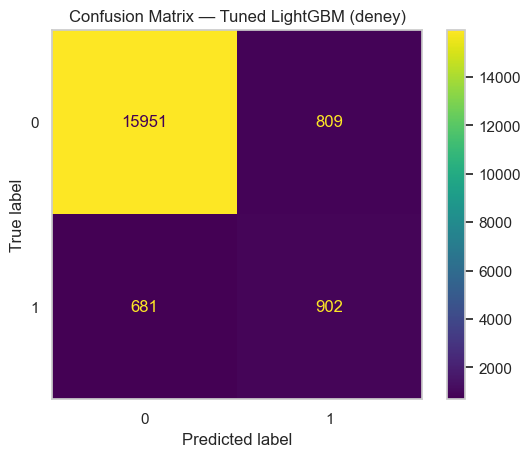

In [30]:
ConfusionMatrixDisplay.from_estimator(lgbm_pipe, X_test, y_test)
plt.title("Confusion Matrix — Tuned LightGBM (deney)")
plt.grid(False)
plt.show()


In [32]:
from sklearn.metrics import f1_score


y_pred_hpo = lgbm_pipe.predict(X_test)

print(
    "\nHPO ve Eşik Optimizasyonu sonrası LightGBM — Test F1 (macro):",
    f1_score(y_test, y_pred_hpo, average="macro"),
)
y_proba_hpo = lgbm_pipe.predict_proba(X_test)[:, 1]
print("ROC-AUC (HPO-LightGBM):", roc_auc_score(y_test, y_proba_hpo))


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



HPO ve Eşik Optimizasyonu sonrası LightGBM — Test F1 (macro): 0.7515204751477109


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC-AUC (HPO-LightGBM): 0.9105079778131911


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


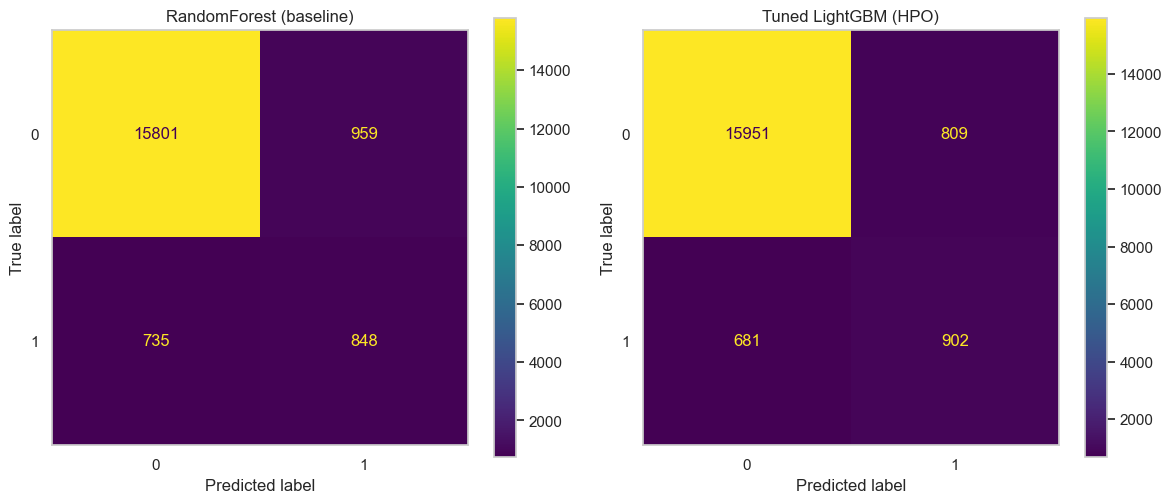

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

rf_pipe = pipelines["RandomForest"]   # daha önce fit edilmişti

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(rf_pipe, X_test, y_test, ax=axes[0])
axes[0].set_title("RandomForest (baseline)")
axes[0].grid(False)

ConfusionMatrixDisplay.from_estimator(lgbm_pipe, X_test, y_test, ax=axes[1])
axes[1].set_title("Tuned LightGBM (HPO)")
axes[1].grid(False)

plt.tight_layout()
plt.show()


In [34]:
from sklearn.metrics import confusion_matrix

for name, pipe in [("RandomForest", pipelines["RandomForest"]), ("Tuned LightGBM", lgbm_pipe)]:
    tn, fp, fn, tp = confusion_matrix(y_test, pipe.predict(X_test)).ravel()
    print(f"{name}: TN={tn}  FP={fp}  FN={fn}  TP={tp}")


RandomForest: TN=15801  FP=959  FN=735  TP=848


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Tuned LightGBM: TN=15951  FP=809  FN=681  TP=902


In [38]:
from sklearn.metrics import recall_score, precision_score, f1_score

y_proba = lgbm_pipe.predict_proba(X_test)[:, 1]

for thresh in np.linspace(0.10, 0.85, num=25):
    y_pred_thresh = (y_proba >= thresh).astype(int)
    rec  = recall_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    f1   = f1_score(y_test, y_pred_thresh)
    print(f"Eşik: {thresh:.3f} | Recall: {rec:.3f} | Precision: {prec:.3f} | F1: {f1:.3f}")


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Eşik: 0.100 | Recall: 0.983 | Precision: 0.156 | F1: 0.269
Eşik: 0.131 | Recall: 0.968 | Precision: 0.173 | F1: 0.294
Eşik: 0.163 | Recall: 0.955 | Precision: 0.190 | F1: 0.317
Eşik: 0.194 | Recall: 0.935 | Precision: 0.205 | F1: 0.336
Eşik: 0.225 | Recall: 0.917 | Precision: 0.220 | F1: 0.355
Eşik: 0.256 | Recall: 0.901 | Precision: 0.235 | F1: 0.372
Eşik: 0.287 | Recall: 0.885 | Precision: 0.248 | F1: 0.387
Eşik: 0.319 | Recall: 0.871 | Precision: 0.264 | F1: 0.405
Eşik: 0.350 | Recall: 0.857 | Precision: 0.280 | F1: 0.422
Eşik: 0.381 | Recall: 0.840 | Precision: 0.293 | F1: 0.434
Eşik: 0.412 | Recall: 0.825 | Precision: 0.309 | F1: 0.450
Eşik: 0.444 | Recall: 0.806 | Precision: 0.326 | F1: 0.464
Eşik: 0.475 | Recall: 0.783 | Precision: 0.343 | F1: 0.477
Eşik: 0.506 | Recall: 0.768 | Precision: 0.365 | F1: 0.494
Eşik: 0.537 | Recall: 0.751 | Precision: 0.383 | F1: 0.507
Eşik: 0.569 | Recall: 0.729 | Precision: 0.397 | F1: 0.514
Eşik: 0.600 | Recall: 0.704 | Precision: 0.420 | F1: 0.5

In [41]:
for thresh in np.linspace(0.30, 0.85, num=25):
    y_pred_thresh = lgbm_pipe.predict_proba(X_test)[:, 1] > thresh
    print(f"Eşik: {thresh:.3f}")
    print(classification_report(y_test, y_pred_thresh, digits=4))
    print("-" * 50)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Eşik: 0.300
              precision    recall  f1-score   support

           0     0.9853    0.7560    0.8555     16760
           1     0.2542    0.8806    0.3945      1583

    accuracy                         0.7667     18343
   macro avg     0.6197    0.8183    0.6250     18343
weighted avg     0.9222    0.7667    0.8157     18343

--------------------------------------------------


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Eşik: 0.323
              precision    recall  f1-score   support

           0     0.9841    0.7731    0.8659     16760
           1     0.2653    0.8673    0.4063      1583

    accuracy                         0.7812     18343
   macro avg     0.6247    0.8202    0.6361     18343
weighted avg     0.9220    0.7812    0.8262     18343

--------------------------------------------------


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

Eşik: 0.804
              precision    recall  f1-score   support

           0     0.9519    0.9724    0.9621     16760
           1     0.6219    0.4801    0.5419      1583

    accuracy                         0.9299     18343
   macro avg     0.7869    0.7263    0.7520     18343
weighted avg     0.9235    0.9299    0.9258     18343

--------------------------------------------------


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Eşik: 0.827
              precision    recall  f1-score   support

           0     0.9492    0.9771    0.9630     16760
           1     0.6486    0.4466    0.5290      1583

    accuracy                         0.9314     18343
   macro avg     0.7989    0.7119    0.7460     18343
weighted avg     0.9233    0.9314    0.9255     18343

--------------------------------------------------


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Eşik: 0.850
              precision    recall  f1-score   support

           0     0.9461    0.9820    0.9637     16760
           1     0.6811    0.4075    0.5099      1583

    accuracy                         0.9324     18343
   macro avg     0.8136    0.6947    0.7368     18343
weighted avg     0.9232    0.9324    0.9245     18343

--------------------------------------------------
